In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("telco-Customer-churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.drop("customerID",axis=1,inplace=True)

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce")

In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df['TotalCharges']=df["TotalCharges"].fillna(df["TotalCharges"].median())

In [12]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df.duplicated().sum()


np.int64(22)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()


np.int64(0)

In [17]:
df.shape

(7021, 20)

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


univarate anaylisis

<Axes: xlabel='SeniorCitizen', ylabel='count'>

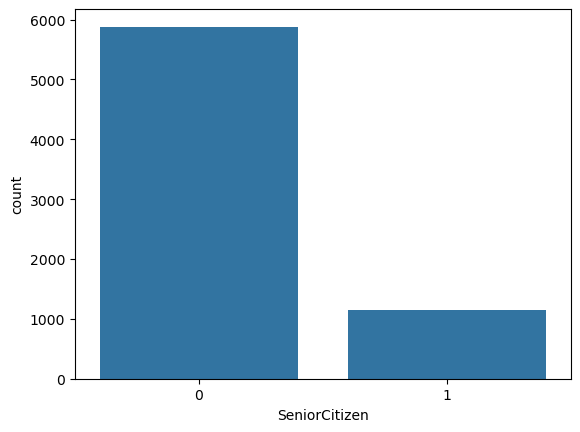

In [19]:
sns.countplot(data=df,x="SeniorCitizen")

sns.hist

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

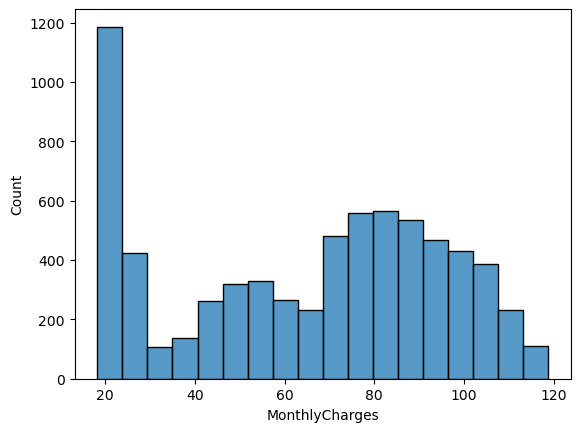

In [20]:
sns.histplot(data=df,x="MonthlyCharges")

<Axes: xlabel='tenure', ylabel='Count'>

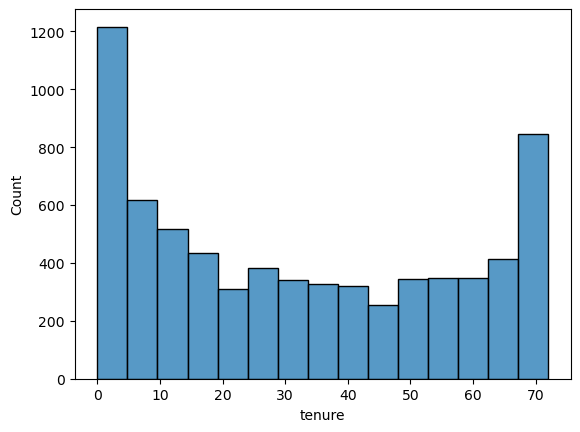

In [21]:
sns.histplot(df['tenure'])

bivarite anaylisis

<Axes: xlabel='Contract', ylabel='count'>

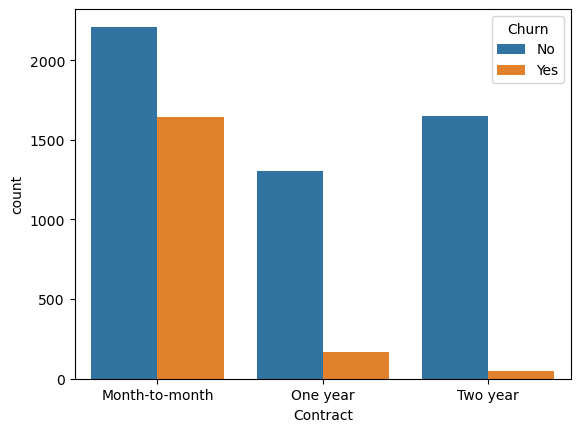

In [22]:
sns.countplot(data=df,x="Contract",hue="Churn")

<Axes: xlabel='PaymentMethod', ylabel='count'>

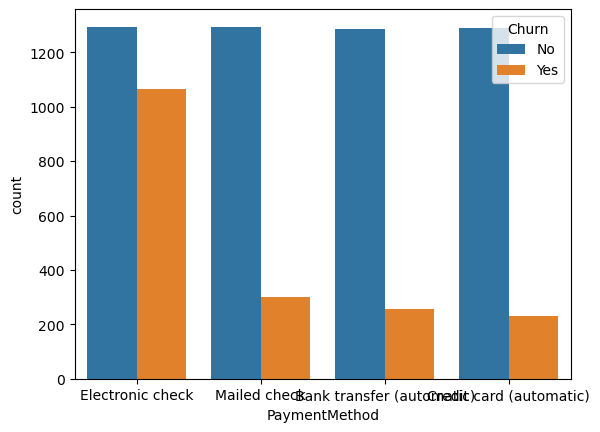

In [23]:
sns.countplot(data=df,x="PaymentMethod",hue="Churn")

<Axes: xlabel='InternetService', ylabel='count'>

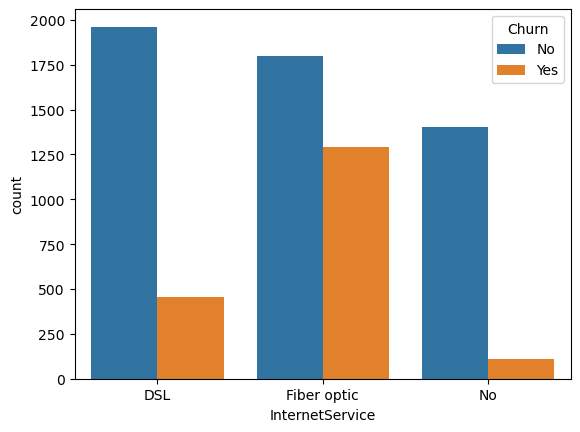

In [24]:
sns.countplot(data=df,x="InternetService",hue="Churn")

In [25]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [26]:
df=pd.get_dummies(df,drop_first=True).astype(int)

In [27]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84,1990,1,1,1,1,0,1,...,1,0,1,1,0,1,0,0,1,0
7039,0,72,103,7362,0,1,1,1,0,1,...,1,0,1,1,0,1,1,0,0,0
7040,0,11,29,346,0,1,1,0,1,0,...,0,0,0,0,0,1,0,1,0,0
7041,1,4,74,306,1,1,0,1,0,1,...,0,0,0,0,0,1,0,0,1,1


In [28]:
from sklearn.model_selection import train_test_split
x=df.drop("Churn_Yes",axis=1)
y=df['Churn_Yes']

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler    
scale=StandardScaler()
x1=scale.fit_transform(x_train)
y1=scale.transform(x_test)

In [31]:
from sklearn.linear_model import LogisticRegression
logistic_model=LogisticRegression()
logistic_model.fit(x1,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
logpred=logistic_model.predict(y1)

In [33]:
logpred

array([1, 0, 0, ..., 0, 0, 0], shape=(1405,))

In [34]:
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score,confusion_matrix
f1_score(y_test,logpred)

0.5654761904761905

In [35]:
accuracy  = accuracy_score(y_test, logpred)
precision = precision_score(y_test, logpred)
recall    = recall_score(y_test, logpred)
f1        = f1_score(y_test, logpred)

# 3. Print the performance report
print("--- Logistic Regression Baseline Performance ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (When it claims Churn, how often is it right?)")
print(f"Recall    : {recall:.4f}     (Of all actual Churners, how many did it catch?)")
print(f"F1-Score  : {f1:.4f}         (Harmonic mean of Precision & Recall)")
print("-" * 48)

# 4. Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, logpred)
print("Confusion Matrix:\n", cm)

--- Logistic Regression Baseline Performance ---
Accuracy  : 0.7922
Precision : 0.5938  (When it claims Churn, how often is it right?)
Recall    : 0.5398     (Of all actual Churners, how many did it catch?)
F1-Score  : 0.5655         (Harmonic mean of Precision & Recall)
------------------------------------------------
Confusion Matrix:
 [[923 130]
 [162 190]]


In [36]:
from sklearn.neighbors import KNeighborsClassifier
modelknn=KNeighborsClassifier(n_neighbors=5)


In [37]:
modelknn.fit(x1,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
knnpred=modelknn.predict(y1)

In [39]:
accuracy  = accuracy_score(y_test, knnpred)
precision = precision_score(y_test, knnpred)
recall    = recall_score(y_test, knnpred)
f1        = f1_score(y_test, knnpred)

# 3. Print the performance report
print("--- KNN  Baseline Performance ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (When it claims Churn, how often is it right?)")
print(f"Recall    : {recall:.4f}     (Of all actual Churners, how many did it catch?)")
print(f"F1-Score  : {f1:.4f}         (Harmonic mean of Precision & Recall)")
print("-" * 48)

# 4. Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, logpred)
print("Confusion Matrix:\n", cm)

--- KNN  Baseline Performance ---
Accuracy  : 0.7516
Precision : 0.5042  (When it claims Churn, how often is it right?)
Recall    : 0.5142     (Of all actual Churners, how many did it catch?)
F1-Score  : 0.5091         (Harmonic mean of Precision & Recall)
------------------------------------------------
Confusion Matrix:
 [[923 130]
 [162 190]]


In [40]:
from sklearn.svm import SVC
svmmodel=SVC()
svmmodel.fit(x1,y_train)
svmpred=svmmodel.predict(y1)

In [41]:
accuracy  = accuracy_score(y_test, svmpred)
precision = precision_score(y_test, svmpred)
recall    = recall_score(y_test, svmpred)
f1        = f1_score(y_test, svmpred)

# 3. Print the performance report
print("--- svm  Baseline Performance ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (When it claims Churn, how often is it right?)")
print(f"Recall    : {recall:.4f}     (Of all actual Churners, how many did it catch?)")
print(f"F1-Score  : {f1:.4f}         (Harmonic mean of Precision & Recall)")
print("-" * 48)

# 4. Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, logpred)
print("Confusion Matrix:\n", cm)

--- svm  Baseline Performance ---
Accuracy  : 0.7964
Precision : 0.6138  (When it claims Churn, how often is it right?)
Recall    : 0.5057     (Of all actual Churners, how many did it catch?)
F1-Score  : 0.5545         (Harmonic mean of Precision & Recall)
------------------------------------------------
Confusion Matrix:
 [[923 130]
 [162 190]]


In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
des_model=DecisionTreeClassifier()
rand_model=RandomForestClassifier()


In [43]:
des_model.fit(x_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [44]:
rand_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
despred=des_model.predict(x_test)
randpred=rand_model.predict(x_test)

In [46]:
accuracy  = accuracy_score(y_test, despred)
precision = precision_score(y_test, despred)
recall    = recall_score(y_test, despred)
f1        = f1_score(y_test, despred)

# 3. Print the performance report
print("--- DESICION TREE  Baseline Performance ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (When it claims Churn, how often is it right?)")
print(f"Recall    : {recall:.4f}     (Of all actual Churners, how many did it catch?)")
print(f"F1-Score  : {f1:.4f}         (Harmonic mean of Precision & Recall)")
print("-" * 48)

# 4. Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, logpred)
print("Confusion Matrix:\n", cm)

--- DESICION TREE  Baseline Performance ---
Accuracy  : 0.7253
Precision : 0.4548  (When it claims Churn, how often is it right?)
Recall    : 0.4858     (Of all actual Churners, how many did it catch?)
F1-Score  : 0.4698         (Harmonic mean of Precision & Recall)
------------------------------------------------
Confusion Matrix:
 [[923 130]
 [162 190]]


In [47]:
accuracy  = accuracy_score(y_test, randpred)
precision = precision_score(y_test, randpred)
recall    = recall_score(y_test, randpred)
f1        = f1_score(y_test, randpred)

# 3. Print the performance report
print("--- RANDOM FOREST  Baseline Performance ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (When it claims Churn, how often is it right?)")
print(f"Recall    : {recall:.4f}     (Of all actual Churners, how many did it catch?)")
print(f"F1-Score  : {f1:.4f}         (Harmonic mean of Precision & Recall)")
print("-" * 48)

# 4. Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, logpred)
print("Confusion Matrix:\n", cm)

--- RANDOM FOREST  Baseline Performance ---
Accuracy  : 0.7872
Precision : 0.5923  (When it claims Churn, how often is it right?)
Recall    : 0.4830     (Of all actual Churners, how many did it catch?)
F1-Score  : 0.5321         (Harmonic mean of Precision & Recall)
------------------------------------------------
Confusion Matrix:
 [[923 130]
 [162 190]]


NOW AGAIN WORKING ON THE MODEL AFTER APPLYING CROSSVALIDATION


In [48]:
from sklearn.model_selection import cross_val_score

In [59]:
from sklearn.model_selection import cross_val_score


scores = cross_val_score(logistic_model, x1, y_train, cv=5, scoring='accuracy')

# Scores ko print karein
print("All 5 Folds Scores:", scores)
print(f"Mean Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

All 5 Folds Scores: [0.82117438 0.8032057  0.80142476 0.80409617 0.80498664]
Mean Accuracy: 0.8070 (+/- 0.0144)


In [54]:
x1.shape

(5616, 30)

In [55]:
y1.shape

(1405, 30)

In [63]:
logistic_model_score=cross_val_score(logistic_model,x1,y_train,cv=5,scoring="accuracy")
logistic_model_score.mean()

np.float64(0.8069775290512513)

In [66]:
modelknn_score=cross_val_score(modelknn,x1,y_train,cv=5,scoring="accuracy")
print(modelknn_score)
print(modelknn_score.mean())

[0.76601423 0.76135352 0.75066785 0.75690116 0.75957257]
0.7589018674559438


In [67]:
svmmodel_score=cross_val_score(svmmodel,x1,y_train,cv=5,scoring="accuracy")
print(svmmodel_score)
print(svmmodel_score.mean())

[0.81049822 0.79162956 0.79252004 0.80409617 0.7969724 ]
0.7991432772536704


In [68]:
des_model_score=cross_val_score(des_model,x1,y_train,scoring="accuracy")
print(des_model_score)
print(des_model_score.mean())

[0.74288256 0.72484417 0.70881567 0.70881567 0.7364203 ]
0.7243556754118827


In [69]:

rand_model_score=cross_val_score(rand_model,x1,y_train,scoring="accuracy")
print(rand_model_score)
print(rand_model_score.mean())

[0.79181495 0.79430098 0.78539626 0.77114871 0.80142476]
0.7888171300184115


In [71]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM'
    ],
    'CV Score': [
        logistic_model_score.mean(),
        modelknn_score.mean(),
        des_model_score.mean(),
        rand_model_score.mean(),
        svmmodel_score.mean()
    ]})
results

,Model,CV Score
0,Logistic Regression,0.806978
1,KNN,0.758902
2,Decision Tree,0.724356
3,Random Forest,0.788817
4,SVM,0.799143


In [72]:
from sklearn.model_selection import GridSearchCV


pg = {
    'n_estimators': [50,100,200],
    'max_depth': [3,5,10]
}


In [79]:
grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = pg,
    cv=5, scoring='accuracy')
grid

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [76]:
grid.fit(x,y)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [78]:
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 50}


In [92]:
knnpg = {
    'n_neighbors': [3,5,7]
}

In [93]:
gridofknn=GridSearchCV(
    estimator=KNeighborsClassifier(),
         param_grid = knnpg,
    cv=5, scoring='accuracy'
    
)

In [94]:
gridofknn.fit(x1, y_train)

print("Best Parameters:", gridofknn.best_params_)
print("Best Accuracy:", gridofknn.best_score_)

Best Parameters: {'n_neighbors': 7}
Best Accuracy: 0.7660229494585866
